In [1]:
import librosa
import soundfile as sf
from scipy.signal import medfilt
import numpy as np

# V1
def denoise_audio_librosa(filename, output_name):
    # 1. Load audio (librosa automatically converts to float and handles mono)
    y, sr = librosa.load(filename, sr=None)
    
    # 2. Compute STFT
    s_full, phase = librosa.magphase(librosa.stft(y))
    
    noise_power = np.mean(s_full[:, :int(sr * 0.1)], axis=1)

    mask = s_full > noise_power[:, None]

    mask = mask.astype(float)
    mask = medfilt(mask, kernel_size=(1,5))
    s_clean = s_full * mask
    y_clean = librosa.istft(s_clean * phase)

    sf.write(output_name, y_clean, sr)

input_file = "./data/noise/audio_4.wav"
output = "output_audio_v1.wav"
denoise_audio_librosa(input_file, output)

c:\Users\USER\miniconda3\envs\fft\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import numpy as np
import librosa
import soundfile as sf
from scipy.ndimage import uniform_filter1d

# V2 Spectral Subtraction with Temporal Smoothing
def spectral_subtraction_temporal_smoothing(filename, output_name):
    # Load
    y, sr = librosa.load(filename, sr=None)
    
    # 2. STFT - Use a larger window (2048) for smoother frequency transitions
    n_fft = 2048
    hop_length = 512
    stft_full = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    s_full, phase = librosa.magphase(stft_full)
    
    # Estimate Noise (First 0.5s)
    noise_mu = np.mean(s_full[:, :int(librosa.time_to_frames(0.5, sr=sr))], axis=1, keepdims=True)
    
    # Calculate Gain Mask
    # alpha = how much noise to kill (1.0 to 2.0)
    # beta = how much original signal to ALWAYS keep (0.1 = 10%)
    alpha = 1.5 
    beta = 0.15 
    
    # Basic subtraction mask
    mask = (s_full - alpha * noise_mu) / s_full
    
    # Clip mask between beta and 1.0 (This is the most important part!)
    # By staying above 'beta', we never get those "zero-energy" holes that sound robotic.
    mask = np.clip(mask, beta, 1.0)
    
    # Temporal Smoothing (The "Anti-Robot" Step)
    # This blurs the mask across time (axis 1) so changes are gradual.
    mask = uniform_filter1d(mask, size=7, axis=1) 
    

    s_clean = s_full * mask
    y_clean = librosa.istft(s_clean * phase, hop_length=hop_length)
    
    sf.write(output_name, y_clean, sr)

input_file = "./data/noise/audio_4.wav"
output = "output_audio_v2.wav"
spectral_subtraction_temporal_smoothing(input_file, output)

C:\Users\USER\AppData\Local\Temp\ipykernel_29212\1716528854.py:27: RuntimeWarning: divide by zero encountered in divide
  mask = (s_full - alpha * noise_mu) / s_full


In [ ]:
import numpy as np
import librosa
import soundfile as sf
from scipy.ndimage import uniform_filter1d

def denoise_wiener_style(filename, output_name):
    y, sr = librosa.load(filename, sr=None)
    
    # STFT (Larger window = higher frequency resolution)
    n_fft = 2048
    hop_length = 512
    stft_full = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    s_full, phase = librosa.magphase(stft_full)
    
    # Power Spectrum (Wiener logic works best on Power)
    power_spec = s_full**2
    
    # Estimate Noise Power (First 0.5s)
    noise_power = np.mean(power_spec[:, :int(librosa.time_to_frames(0.5, sr=sr))], axis=1, keepdims=True)
    
    # Wiener Gain Calculation
    # G = Signal_Power / (Signal_Power + Noise_Power)
    # We add 1e-10 to avoid dividing by zero
    mask = power_spec / (power_spec + noise_power + 1e-10)
    
    # Apply Safety Nets (The "Anti-Robot" steps)
    beta = 0.15 # Minimum noise floor (keeps it sounding natural)
    mask = np.clip(mask, beta, 1.0)
    
    # Temporal Smoothing (prevents rapid "flickering" of frequencies)
    mask = uniform_filter1d(mask, size=7, axis=1) 
    s_clean = s_full * mask

    y_clean = librosa.istft(s_clean * phase, hop_length=hop_length)
    
    sf.write(output_name, y_clean, sr)


input_file = "./data/noise/audio_4.wav"
output = "output_audio_v3.wav"
denoise_wiener_style(input_file, output)

In [ ]:
import numpy as np
import librosa
import soundfile as sf
from scipy.ndimage import median_filter, uniform_filter1d

def denoise_adaptive(filename, output_name):
    y, sr = librosa.load(filename, sr=None)
    stft_full = librosa.stft(y, n_fft=2048, hop_length=512)
    s_full, phase = librosa.magphase(stft_full)

    # Switch to Power Domain for better noise separation
    power_spec = s_full**2

    # Instead of minimum, use a median filter across time (axis 1)
    # This captures the 'average' background noise much better.
    window_size = int(librosa.time_to_frames(1.5, sr=sr, hop_length=512))
    
    # We estimate noise as the median energy in each frequency band over time
    # Using a 2D median filter or 1D median on the time axis
    noise_est = median_filter(power_spec, size=(1, window_size))

    # Aggressive Subtraction
    # Increase alpha if noise persists (try 2.0 to 4.0)
    alpha = 3.0  
    beta = 0.05  # Lower floor for a "darker" background
    
    # Subtract noise in power domain
    subtracted = power_spec - (alpha * noise_est)
    
    # Apply the mask
    # We ensure we don't go below our 'beta' floor
    mask = np.maximum(subtracted, beta * power_spec) / (power_spec + 1e-10)
    mask = np.sqrt(np.clip(mask, 0, 1)) # Back to magnitude domain

    # Smoothing (Crucial for "musical noise" reduction)
    mask = uniform_filter1d(mask, size=5, axis=1) # Time smoothing
    mask = uniform_filter1d(mask, size=3, axis=0) # Freq smoothing

    s_clean = s_full * mask
    y_clean = librosa.istft(s_clean * phase, hop_length=512)
    
    y_clean = librosa.util.normalize(y_clean)
    sf.write(output_name, y_clean, sr)

input_file = "./data/noise/audio_4.wav"
output = "output_audio_v4.wav"
denoise_adaptive(input_file, output)

These three scripts represent an evolution in Digital Signal Processing (DSP) for noise reduction. They all operate in the Frequency Domain using the Short-Time Fourier Transform (STFT), but they differ in how they decide which "pixels" of sound to keep and which to throw away

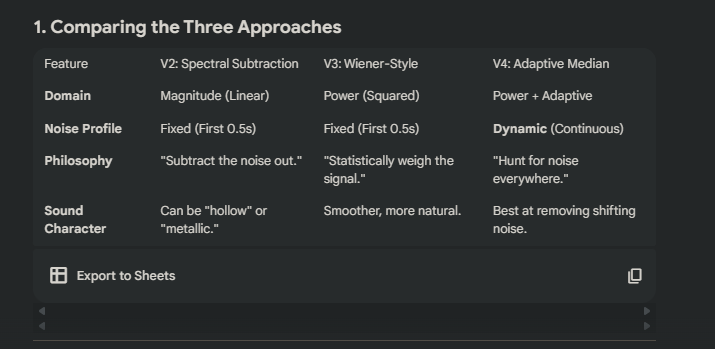

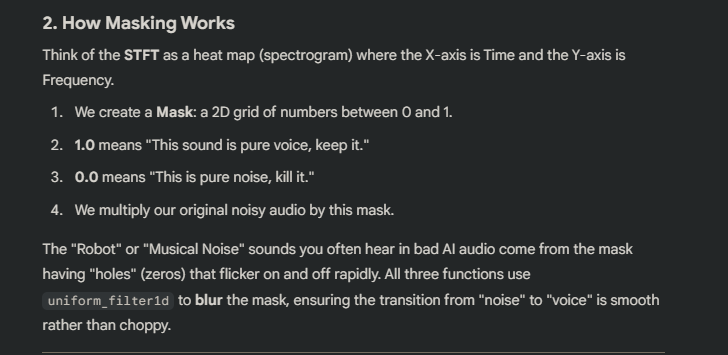

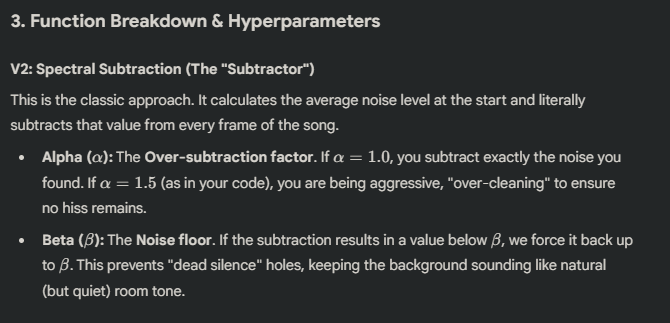

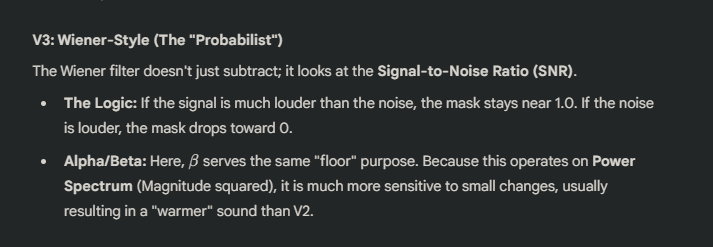

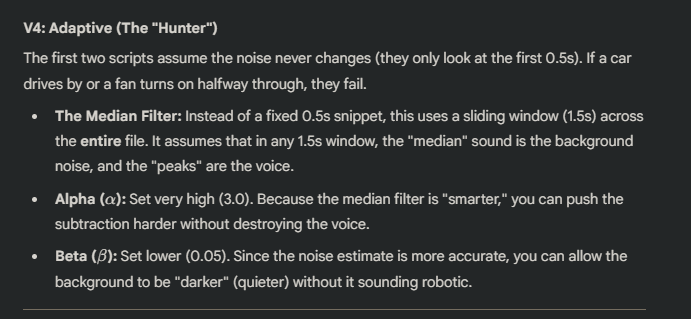